# Predicting Airbnb Listing Prices in Brisbane, Australia

Kaggle regression competition, BUSA8001 (Macquarie University), Semester 1 2026.

**Team BUSA8001_Gaggle:** Jarernrat Srimaothongsuk, Harisha Sundaram, Rakshith Krishna Suresh Hema

- Task 1 (Problem description & EDA): Harisha Sundaram
- Task 2 (Data cleaning & feature engineering): Rakshith Krishna Suresh Hema
- Task 3 (Modelling, tuning & prediction): Jarernrat Srimaothongsuk

Place `train.csv` and `test.csv` in a `Dataset/` folder (or next to this notebook) before running.

---
## Part 1: Problem Description and Exploratory Data Analysis
*Section lead: Harisha Sundaram*

### 1.1 Forecasting Problem

The forecasting problem for this competition is, predicting the listing price of *Airbnb* properties in *Brisbane, Australia*. The target variable is `price`, representing the nightly listing price of each Airbnb property. Since `price` is a continuous numerical variable, it is a supervised regression problem than a classification problem. The training dataset contains listings where the price is known, while the test dataset contains similar listing information but without the target price. The aim is to use property, host, location, availability and review-related information to estimate the missing prices as accurately as possible.

This problem has a clear real-world business application because short-term rental prices are not fixed in the same way as many traditional products. Airbnb prices can change depending on the type of property, number of guests accommodated, bedrooms, bathrooms, location, availability, host quality and review performance. Previous research on Airbnb pricing also shows that accommodation prices are affected by property attributes, location and host/review characteristics (Wang & Nicolau, 2017). Therefore, the dataset can be used to understand which listing characteristics are associated with higher or lower prices.

Several stakeholders may benefit from these predictions. Hosts can use predicted prices to compare their current price with similar listings and make more competitive pricing decisions. Guests can use price predictions to understand whether a listing appears expensive or reasonable compared with similar accommodation. Airbnb or other platform managers could use this type of analysis to improve pricing recommendation tools and listing quality checks. Property investors and tourism analysts may also benefit because predicted prices can help them understand demand patterns and the revenue potential of different property types or neighbourhoods. Overall, the forecasting task supports better pricing decisions by turning listing-level data into practical business insight.

**Rerferences:** 
- Wang, D., & Nicolau, J. L. (2017). Price Determinants of Sharing Economy Based Accommodation Rental: A Study of Listings from 33 Cities on Airbnb.com. International Journal of Hospitality Management, 62, 120-131. [ https://doi.org/10.1016/j.ijhm.2016.12.007 ]


### 1.2 Evaluation Metric

The evaluation metric used in this competition to assess forecasting performance is **Mean Absolute Percentage Error (MAPE)**, used to measure the average absolute size of prediction error as a percentage of the Actual Value. In this competition, a lower MAPE means the predicted Airbnb prices are closer to the Actual Prices.

**The formula =**
$$
MAPE = \frac{1}{n}\sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%
$$ 

Where:
- $n$ = Number of Observations
- $y_i$ = actual Airbnb Listing Price
- $\hat{y}_i$ = Predicted Airbnb Listing Price
- $|y_i-\hat{y}_i|$ = Absolute Prediction Error


**Advantages of MAPE:**  
A major advantage of MAPE is that it is easy to understand, as the error is expressed in percentage rather than in dollars. For example, if a model has a MAPE of 15%, this means that, on average, the predicted prices differ from the actual prices by about 15%. This makes the result easier to explain to non-technical users, such as Airbnb hosts, property managers or business decision-makers. MAPE is also useful in this Airbnb price prediction task because listing prices may vary widely between cheaper private rooms and more expensive entire homes. Since MAPE is scale-independent, it allows prediction errors to be compared across listings with different price levels.

Another advantage is, MAPE focuses on relative error rather than absolute dollar error. This is useful in pricing problems because a $50 error has different meaning for a \$100 listing compared with a \$500 listing. By converting the error into percentage, MAPE gives a clearer view of how large the prediction error is relative to the actual price.

**Limitations of MAPE:**  
A limitation of MAPE is that it can become unstable when actual values are very small because the formula divides by the actual value. If the actual value is zero, MAPE becomes undefined, and if the actual value is close to zero, the percentage error can become extremely large. **Hyndman and Koehler (2006)** explain that percentage-based forecast accuracy measures can be misleading when actual values are zero or close to zero. In this Airbnb dataset, prices are positive, so zero-value issues are less likely to be a major problem. However, MAPE can still place stronger penalties on errors for cheaper listings because the same dollar error becomes larger percentage of a low actual price.

Another limitation is that MAPE may not treat high-priced and low-priced listings equally from a business perspective. For example, an error of \$50 on a \$100 listing gives a 50% error, while the same \$50 error on a $500 listing gives only a 10% error. This means the model may appear to perform worse when it makes errors on lower-priced listings. Therefore, although MAPE is useful and easy to interpret, it should be considered together with practical business judgement when evaluating Airbnb price predictions.

**References:**
- Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting, 22*(4), 679–688. [https://www.sciencedirect.com/science/article/abs/pii/S0169207006000239?via%3Dihub]

### 1.3 Missing Values

In [14]:
#importing all the requied libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
#to display more columns 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [18]:
# Load train dataset using a portable path
# This will work if train.csv is either in the same folder as the notebook
# or inside a Dataset folder.
from pathlib import Path

possible_data_paths = [Path.cwd() / 'Dataset', Path.cwd()]

data_path = None
for path in possible_data_paths:
    if (path / 'train.csv').exists() and (path / 'test.csv').exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError('Could not find train.csv and test.csv. Put them in the notebook folder or in a Dataset folder.')

train = pd.read_csv(data_path / 'train.csv', index_col=0)
train

,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,city scrape,The Nestt,Enjoy a memorable visit when you stay in this ...,NaN,38029254,Mark,2015-07-09,NaN,NaN,within an hour,100%,89%,t,NaN,8.0,"['email', 'phone', 'work_email']",t,t,Rocklea - Acacia Ridge,-27.557320,153.020270,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Hair dryer"", ""Hangers"", ""Fire extinguisher"",...",5,365,5.0,5.0,365.0,365.0,5.0,365.0,12,30,53,328,18,10,1,30,4,100,9700.0,2023-04-27,2025-10-25,4.56,4.61,4.44,4.78,4.61,4.28,4.50,f,8,8,0,0,0.58,$97.00
1,city scrape,Bayside Bliss - By the Water & Near the Airport,"Relax by the water and close to the airport, B...",Wynnum is nestled along Brisbane's sunny south...,33488214,Claire,2015-05-16,"Wynnum, Australia",NaN,within an hour,100%,93%,t,NaN,1.0,"['email', 'phone']",t,t,Wynnum,-27.445790,153.179090,Entire guest suite,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Laundromat nearby"", ""Refrigerator"", ""Bed lin...",1,14,1.0,1.0,14.0,14.0,1.0,14.0,14,15,45,110,16,8,1,14,10,48,9840.0,2024-06-16,2025-11-02,4.94,4.88,5.00,4.94,4.94,4.88,4.69,f,1,1,0,0,0.93,$205.00
2,city scrape,Cozy 1 Bedroom Apartment with Infinity Pool,My stunning apartment is located in one of the...,Staying here allows you to experience the neve...,401146490,Hao,2021-05-11,NaN,"Roger and I love traveling, we fell in love wi...",within an hour,100%,100%,f,NaN,7.0,['phone'],t,t,Fortitude Valley,-27.456050,153.032450,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Refrigerator"", ""Essentials"", ""Dishwasher"", ""...",1,365,1.0,2.0,365.0,365.0,1.3,365.0,10,31,50,131,27,16,0,22,17,96,17856.0,2024-03-11,2025-10-11,4.70,4.70,4.67,4.70,4.81,4.67,4.56,t,7,7,0,0,1.33,$186.00
3,city scrape,City Stay-Executive 1.5 Bedroom,Experience modern urban living in our stylish ...,NaN,83183834,John,2016-07-11,"Hamilton, Australia",NaN,within an hour,100%,100%,f,NaN,1.0,"['email', 'phone']",t,t,Newstead - Bowen Hills,-27.451701,153.035454,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Outdoor shower"", ""Exercise equipment"", ""Refr...",21,730,21.0,21.0,730.0,730.0,21.0,730.0,0,0,0,224,0,0,0,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN,$157.00
4,city scrape,Private Oasis! 3Bed/2Bath/1Car ~ 5mins to CBD,Brisbane inner-city living at its best! <br />...,Location (walking)<br /><br />•\t1 min e-Scoot...,3384506,Andy,2012-08-27,"Brisbane, Australia",Brisbane’s Leading Property Management Company...,within an hour,100%,97%,t,NaN,155.0,"['email', 'phone']",t,t,Fortitude Valley,-27.458774,153.038180,Entire rental unit,Entire home/apt,6,2.0,2 baths,3.0,3.0,"[""Refrigerator"", ""Stainless steel single oven""...",7,365,2.0,7.0,365.0,1125.0,6.2,746.0,7,18,31,31,23,23,3,17,0,255,76500.0,2025-04-09,2025-11-09,4.74,4.87,4.87,4.78,4.87,4.83,4.57,f

In [20]:
# Load test dataset using the same portable path
test = pd.read_csv(data_path / 'test.csv', index_col=0)
test

,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3735,city scrape,The perfect inner city location FREE parking,Enjoy a stylish experience at this centrally l...,NaN,35524154,Luke,2015-06-11,"Brisbane, Australia",NaN,within an hour,100%,91%,f,NaN,1.0,"['email', 'phone']",t,t,Brisbane City,-27.469540,153.030670,Entire rental unit,Entire home/apt,4,2.0,2 baths,2.0,2.0,"[""Exercise equipment"", ""Refrigerator"", ""Essent...",2,21,2.0,3.0,21.0,21.0,2.0,21.0,17,32,59,210,110,37,3,27,40,222,51282.0,2023-03-01,2025-11-01,4.75,4.85,4.63,4.86,4.81,4.94,4.76,f,1,1,0,0,3.34
3736,city scrape,Chi11 on the Hill - Cave 2,"In Spring Hill, and walking distance from the ...",NaN,21820096,David,2014-09-26,"Petrie Terrace, Australia",David here. Architect with wife and two kids.,within a day,94%,25%,f,NaN,8.0,"['email', 'phone']",t,t,Spring Hill,-27.459800,153.029980,Private room in home,Private room,1,4.0,4 shared baths,1.0,1.0,"[""Refrigerator"", ""Backyard"", ""Bed linens"", ""Ex...",15,720,2.0,21.0,720.0,720.0,15.0,720.0,9,25,25,75,0,0,0,25,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,7,0,7,0,NaN
3737,city scrape,Kooii Apartments 1 Bedroom Urban View,We offer a fresh and new exclusive collection ...,"Set in the heart of Fortitude Valley, one of B...",508442405,Kooii,2023-04-03,NaN,NaN,within an hour,89%,95%,f,NaN,5.0,"['email', 'phone']",t,t,Fortitude Valley,-27.455900,153.036580,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Exercise equipment"", ""Smoke alarm"", ""Wifi"", ...",1,365,1.0,1.0,999.0,999.0,1.0,999.0,21,51,80,349,20,1,0,42,3,6,2340.0,2023-04-15,2025-06-03,4.85,4.95,4.95,4.75,4.45,4.85,4.60,t,5,5,0,0,0.64
3738,city scrape,Stunning Renovated Heritage 1 Bed Apart 4- 3km...,Welcome!!<br /><br />Beautiful renovated self-...,Location! Location!..... Auchenflower is a ver...,49128857,Laetitia,2015-11-15,"Brisbane City, Australia",My passion is travelling! I love to travel bo...,within an hour,100%,98%,t,NaN,5.0,"['email', 'phone']",t,t,Auchenflower,-27.474421,152.994305,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Refrigerator"", ""Essentials"", ""Free washer \u...",90,365,90.0,90.0,365.0,365.0,90.0,365.0,0,27,57,332,0,0,0,18,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,5,5,0,0,NaN
3739,city scrape,Panoramic views of the CBD skyline -1BR1BR unit,Nestled in the vibrant and highly sought-after...,NaN,490286067,Fangzhou,2022-12-05,NaN,We are a dedicated property management team se...,within an hour,100%,100%,f,NaN,40.0,"['email', 'phone']",t,t,Eagle Farm - Pinkenba,-27.440490,153.070680,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,1.0,"[""Refrigerator"", ""Essentials"", ""Dishwasher"", ""...",2,600,2.0,2.0,99.0,99.0,2.0,99.0,9,29,59,334,33,33,3,22,0,198,44352.0,2025-02-16,2025-11-02,4.67,4.76,4.79,4.42,4.88,4.88,4.61,f,11,11,0,0,3

In [22]:
#to know the data type of train dataset
print("Training dataset info:")
train.dtypes

Training dataset info:


source                                           object
name                                             object
description                                      object
neighborhood_overview                            object
host_id                                           int64
host_name                                        object
host_since                                       object
host_location                                    object
host_about                                       object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate                             object
host_is_superhost                                object
host_neighbourhood                               object
host_listings_count                             float64
host_verifications                               object
host_has_profile_pic                             object
host_identity_verified                          

In [24]:
#to know the data type of test dataset
print("Test dataset info:")
test.dtypes

Test dataset info:


source                                           object
name                                             object
description                                      object
neighborhood_overview                            object
host_id                                           int64
host_name                                        object
host_since                                       object
host_location                                    object
host_about                                       object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate                             object
host_is_superhost                                object
host_neighbourhood                               object
host_listings_count                             float64
host_verifications                               object
host_has_profile_pic                             object
host_identity_verified                          

In [26]:
#to view Head, Tail and Dimensions of the Train dataset 
print("TRAIN:")
#for Head
print("Head of the dataset:")
print(train.head())
#for Tail
print("Tail of the dataset:")
print(train.tail())

TRAIN:
Head of the dataset:
         source                                             name  \
ID                                                                 
0   city scrape                                        The Nestt   
1   city scrape  Bayside Bliss - By the Water & Near the Airport   
2   city scrape      Cozy 1 Bedroom Apartment with Infinity Pool   
3   city scrape                  City Stay-Executive 1.5 Bedroom   
4   city scrape    Private Oasis! 3Bed/2Bath/1Car ~ 5mins to CBD   

                                          description  \
ID                                                      
0   Enjoy a memorable visit when you stay in this ...   
1   Relax by the water and close to the airport, B...   
2   My stunning apartment is located in one of the...   
3   Experience modern urban living in our stylish ...   
4   Brisbane inner-city living at its best! <br />...   

                                neighborhood_overview    host_id host_name  \
ID               

In [28]:
#to view Head, Tail and Dimensions of the Test dataset 
print("TEST:")
#for Head
print("Head of the dataset:")
print(test.head())
#for Tail
print("Tail of the dataset:")
print(test.tail())

TEST:
Head of the dataset:
           source                                               name  \
ID                                                                     
3735  city scrape       The perfect inner city location FREE parking   
3736  city scrape                         Chi11 on the Hill - Cave 2   
3737  city scrape              Kooii Apartments 1 Bedroom Urban View   
3738  city scrape  Stunning Renovated Heritage 1 Bed Apart 4- 3km...   
3739  city scrape    Panoramic views of the CBD skyline -1BR1BR unit   

                                            description  \
ID                                                        
3735  Enjoy a stylish experience at this centrally l...   
3736  In Spring Hill, and walking distance from the ...   
3737  We offer a fresh and new exclusive collection ...   
3738  Welcome!!<br /><br />Beautiful renovated self-...   
3739  Nestled in the vibrant and highly sought-after...   

                                  neighborhood_overvie

In [30]:
#shape of the dataset
print('Training dataset shape:', train.shape)
print('Test dataset shape:', test.shape)

Training dataset shape: (3735, 64)
Test dataset shape: (1601, 63)


In [32]:
#To view the missing vlaues in training dataset
print("Missing Values of Train Dataset:")
train_missing = pd.DataFrame({'Missing Values' : train.isnull().sum(),
                              'Missing Percentage' : (train.isnull().sum() / len(train)) * 100})
train_missing = train_missing[train_missing['Missing Values'] > 0]
train_missing = train_missing.sort_values(by='Missing Values', ascending=False)

train_missing

Missing Values of Train Dataset:


,Missing Values,Missing Percentage
host_neighbourhood,3599,96.358768
neighborhood_overview,1981,53.038822
host_about,1492,39.946452
host_location,818,21.900937
reviews_per_month,437,11.700134
review_scores_rating,437,11.700134
review_scores_accuracy,437,11.700134
review_scores_cleanliness,437,11.700134
review_scores_checkin,437,11.700134
review_scores_communication,437,11.700134


In [34]:
#To view the missing vlaues in test dataset
print("Missing Values of Test Dataset:")
test_missing = pd.DataFrame({'Missing Values' : test.isnull().sum(),
                              'Missing Percentage' : (test.isnull().sum() / len(test)) * 100})
test_missing = test_missing[test_missing['Missing Values'] > 0]
test_missing = test_missing.sort_values(by='Missing Values', ascending=False)

test_missing

Missing Values of Test Dataset:


,Missing Values,Missing Percentage
host_neighbourhood,1536,95.940037
neighborhood_overview,847,52.904435
host_about,618,38.600874
host_location,337,21.049344
reviews_per_month,183,11.430356
review_scores_communication,183,11.430356
last_review,183,11.430356
first_review,183,11.430356
review_scores_cleanliness,183,11.430356
review_scores_checkin,183,11.430356


**Missing Values Interpretation**

The missing values summary shows that both the train and test datasets contain missing values, but the pattern of missing values is very similar for both datasets. The `train dataset` consists ***3,735 observations and 64 columns***, while the `test dataset`consists of ***1,601 observations and 63 columns.*** 
The `Test dataset` had fewer columns cause it does not include the target variable `price`. The missing value table are created using the ***number of missing values and the missing percentage for each column***, which helps in identifying which variabes might require further cleaning before modelling.

In `Train dataset`, the variable with the highest missing values is `host_neighbourhood`, with ***3,599 missing values***, ***~96.36%*** of the train dataset. This is followed by `neighbourhood_overview`, with ***1,981 missing values*** or ***53.04%*** and `host_about` with ***1,492 missing values*** or ***~39.95%.*** 
In `Test dataset` `host_neighbourhood` has the highest misssing values, with ***1,536 missing values*** or ***52.90%*** and `host_about`, with ***618 missing values*** or ***38.60%.***
All these variables are mostly test-based descritive feilds, so their high missingness suggests that many hosts did not provide any detailed profile or neighbourhood information.

Review-realted data variable also contain missing values in both datasets. In the `Train dataset`, varibles such as `review_per_month`, `review_scores_rating`, `review_scores_accuracy`, `review_scores_cleanliness`, `review_scores_location`, `review_scores_value`, `fist_review` and `last_review` each having ***437 missing values***, which is ***~11.70%*** of the dataset.
In `Test dataset`, the same review-related variables have ***183 missing values***, ***~11.43%***, which likely occurs because some listings have not yet received reviews, so review scores and reviews dates are unavailable. 

Host reponse variables also have moderate missingness. In `Train dataset`, `host_response_rate` and `host_response_time`, each have ***287 missing values***, while `host_reponse_rate` has ***201 missing values***. In `Test dataset`, `host_response_rate` and `host_response_time` each have ***121 missing values***, while `host_acceptance_rate` has ***78 missing values***, indicating that some hosts might have not recorded enough response activity or might have not provided information.

Other important property-related variables have very low missingness. For e.g., in `Train dataset`, `bathrooms` has only ***5 missing values***, `beds` has ***3 missing values*** and `bedrooms` has ***2 missing values***. In `Test Dataset`, `bedrooms` and `bathrooms_text` have only ***1 missing value***. This is a positve finding as these variables are likely to be useful for predicting airbnb lisitng prices.

However the missing values pattern is conssitent between `Train` and `Test` datasets. Variables with very high missingness like `host_neighbours`, may be less usefull unless carefully handled or excluded. Review-realted and host-response variable have moderate missingness and might require imputation in later data cleaning. Property realted variables have few missging values, making them more reliable for later feature selection and modelling.

### 1.4 Univariate Analysis

In [38]:
#Creating copies for EDA
train_eda = train.copy()
test_eda = test.copy()

#to convert price into numeric format in training dataset only
train_eda['price'] = train_eda['price'].replace(r'[\$,]', '', regex=True).astype(float)
#and for converting percentage columns into numeric format in both train and test
percentage_columns = ['host_response_rate', 'host_acceptance_rate']

for col in percentage_columns:
    train_eda[col] = train_eda[col].replace('%', '', regex=True).astype(float)
    test_eda[col] = test_eda[col].replace('%', '', regex=True).astype(float)

#to confirm the conversion
print("Training dataset converted columns:")
print(train_eda[['price', 'host_response_rate', 'host_acceptance_rate']].head())

print("\nTest datset converted columns:")
print(test_eda[['host_response_rate', 'host_acceptance_rate']].head())

Training dataset converted columns:
    price  host_response_rate  host_acceptance_rate
ID                                                 
0    97.0               100.0                  89.0
1   205.0               100.0                  93.0
2   186.0               100.0                 100.0
3   157.0               100.0                 100.0
4   300.0               100.0                  97.0

Test datset converted columns:
      host_response_rate  host_acceptance_rate
ID                                            
3735               100.0                  91.0
3736                94.0                  25.0
3737                89.0                  95.0
3738               100.0                  98.0
3739               100.0                 100.0


In [40]:
#Summary statistics for the target variable price
#This helps in understanding the central tendency, spread and extreme values in Airbnb listing prices.
price_summary = train_eda['price'].describe()
print('Summary Statistics for price')
price_summary 

Summary Statistics for price


count    3735.000000
mean      230.082463
std       194.648174
min        36.000000
25%       129.000000
50%       193.000000
75%       267.000000
max      5000.000000
Name: price, dtype: float64

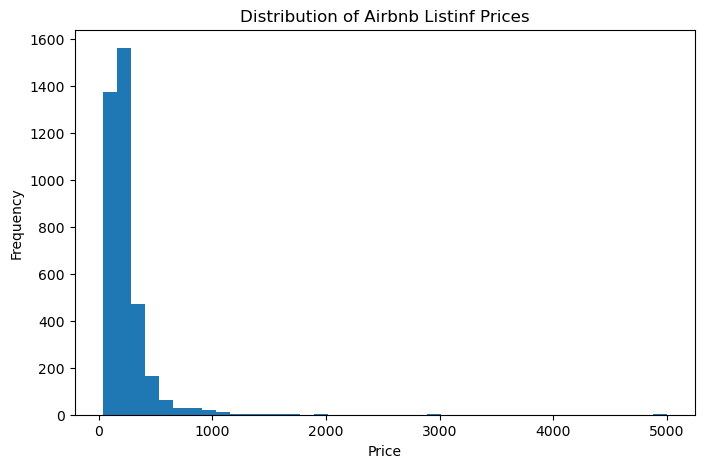

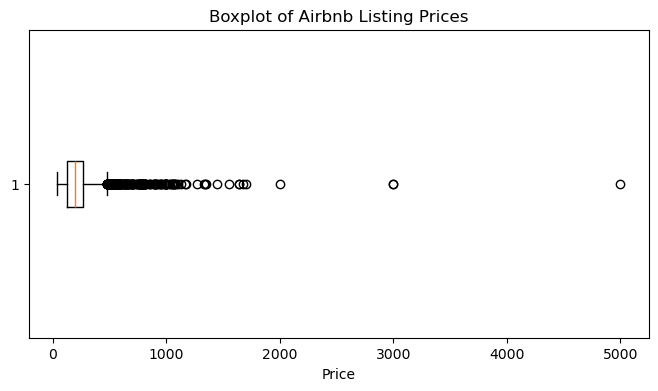

In [42]:
#histogram gor price 
plt.figure(figsize=(8,5))
plt.hist(train_eda['price'], bins=40)
plt.title('Distribution of Airbnb Listinf Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

#Boxplot for price
plt.figure(figsize=(8,4))
plt.boxplot(train_eda['price'].dropna(), vert=False)
plt.title('Boxplot of Airbnb Listing Prices')
plt.xlabel('Price')
plt.show()

In [44]:
#Univariate analyis for Numerical Variables 
numerical_variables = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_30', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month']
#to view summary statistics for the selected numverical variables
train_eda[numerical_variables].describe()

,accommodates,bathrooms,bedrooms,beds,availability_30,availability_365,number_of_reviews,review_scores_rating,reviews_per_month
count,3735.000000,3730.000000,3733.000000,3732.000000,3735.000000,3735.000000,3735.000000,3298.00000,3298.000000
mean,3.702811,1.424129,1.758639,2.117899,12.070147,198.401339,50.595448,4.74248,2.084297
std,2.308905,0.705594,1.110403,1.577968,9.028575,119.506895,90.078291,0.36693,1.808557
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.010000
25%,2.000000,1.000000,1.000000,1.000000,4.000000,83.000000,4.000000,4.67000,0.770000
50%,3.000000,1.000000,1.000000,2.000000,11.000000,192.000000,18.000000,4.83000,1.640000
75%,4.000000,2.000000,2.000000,3.000000,19.000000,322.000000,56.000000,4.95000,2.947500
max,16.000000,9.000000,9.000000,24.000000,30.000000,365.000000,1130.000000,5.00000,13.620000


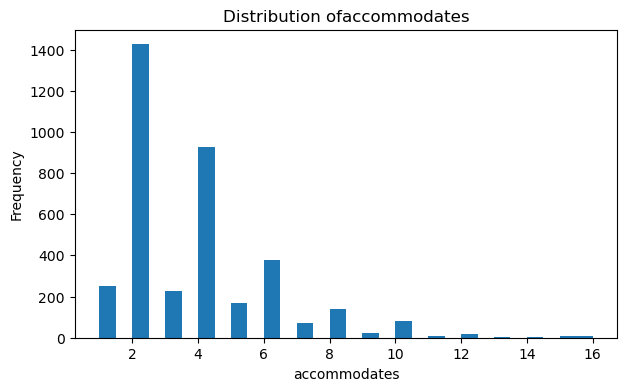

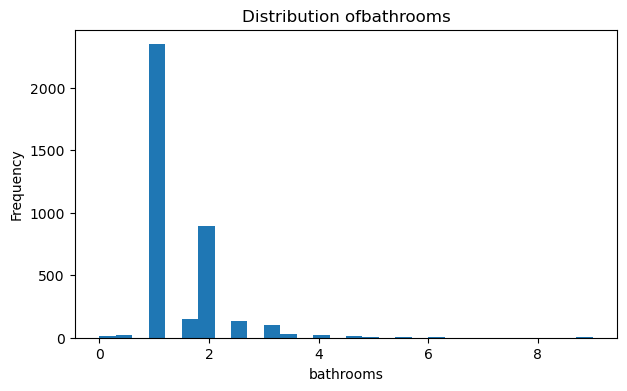

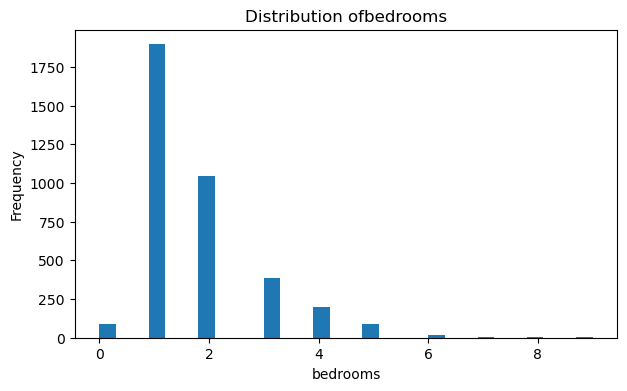

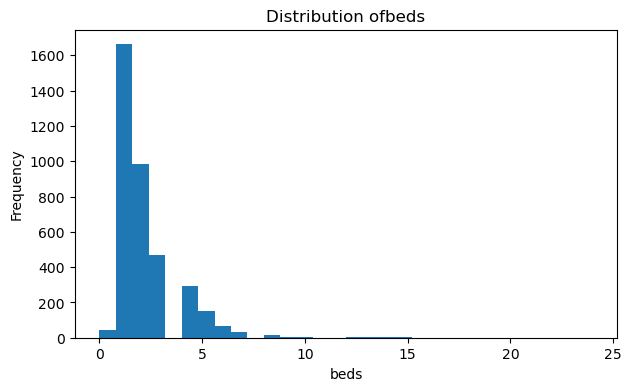

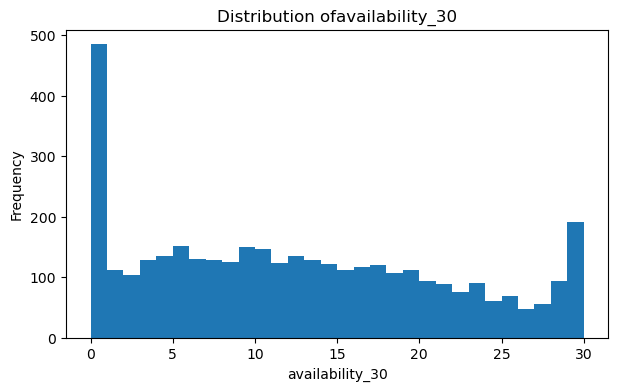

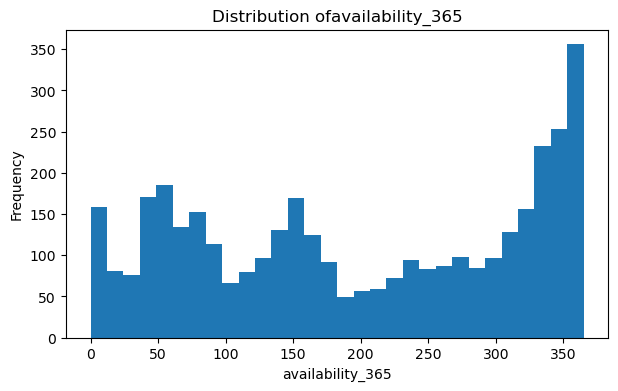

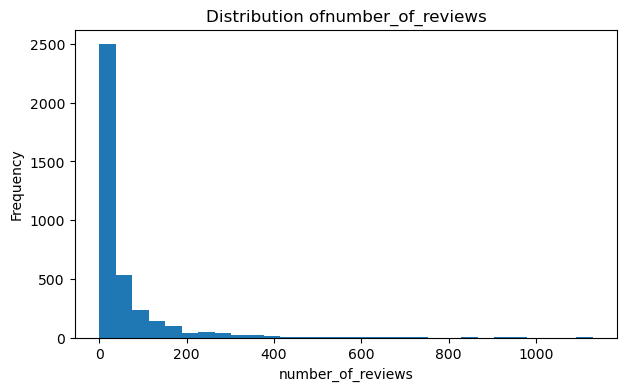

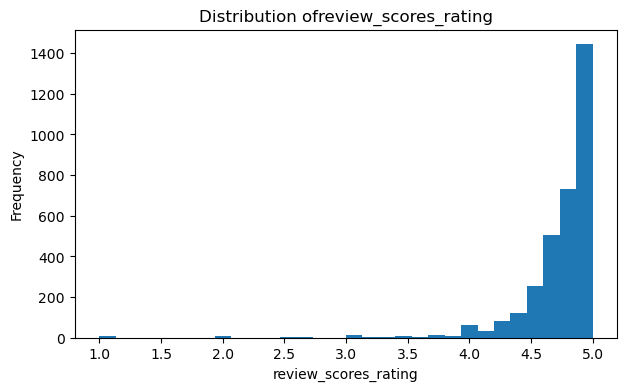

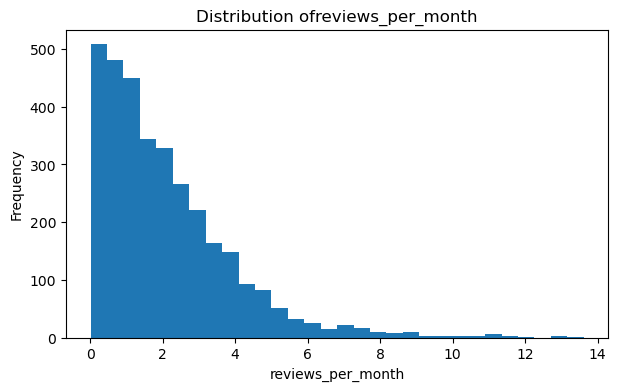

In [46]:
#to visualize
#using histogram for improtnt numerical varialbes 
for col in numerical_variables:
    plt.figure(figsize=(7,4))
    plt.hist(train_eda[col].dropna(), bins=30)
    plt.title('Distribution of'  +  col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [47]:
#Univariate analyis for Categorical Variables 
categorical_variables = ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_is_superhost', 'instant_bookable']
#Frequency tables for the slected categorical variables 
for col in categorical_variables:
    print('\nValue counts for:', col)
    print(train_eda[col].value_counts(dropna=False).head(15))


Value counts for: room_type
room_type
Entire home/apt    2854
Private room        875
Shared room           4
Hotel room            2
Name: count, dtype: int64

Value counts for: property_type
property_type
Entire rental unit                   1804
Entire home                           596
Private room in home                  513
Private room in rental unit           196
Entire guest suite                    122
Entire serviced apartment              96
Entire guesthouse                      88
Entire condo                           50
Entire townhouse                       41
Private room in bed and breakfast      39
Room in hotel                          35
Private room in townhouse              23
Private room in condo                  18
Private room in villa                  17
Private room in guest suite            14
Name: count, dtype: int64

Value counts for: neighbourhood_cleansed
neighbourhood_cleansed
Brisbane City             567
South Brisbane            314
Fortitude V

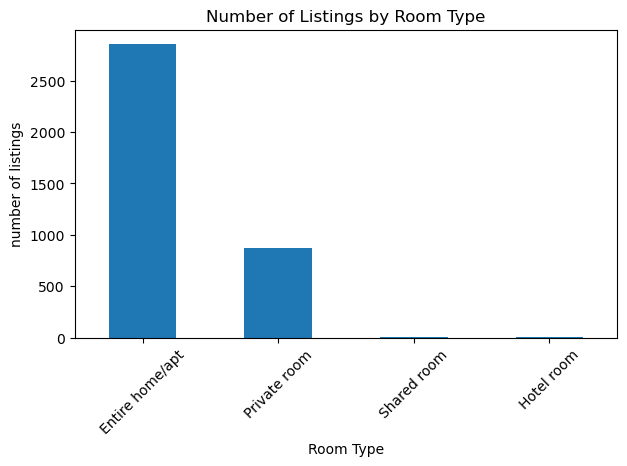

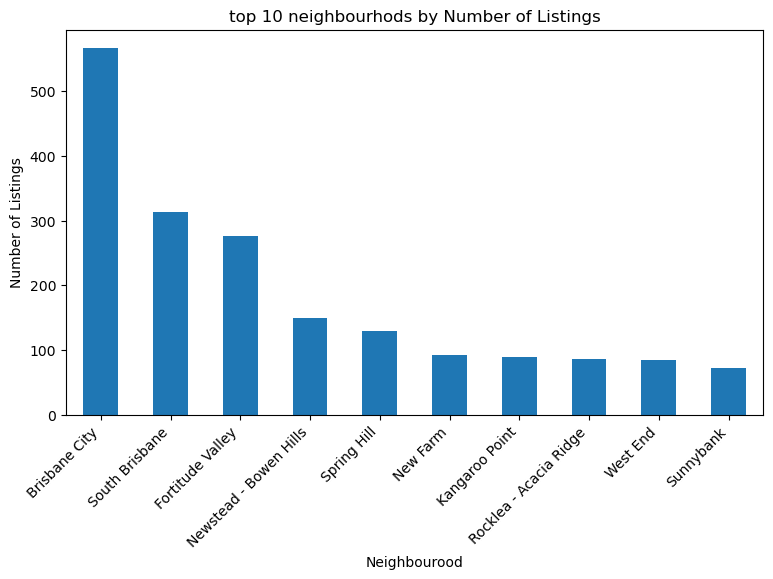

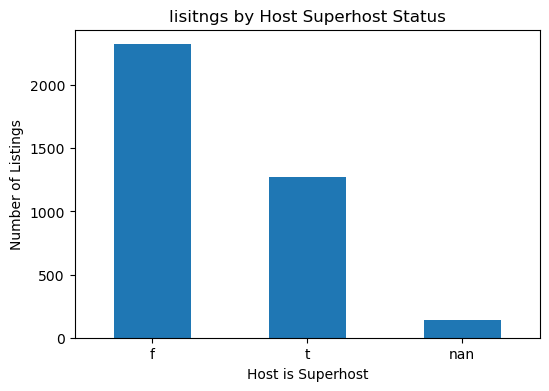

In [50]:
#Visualization 
#Using bar chart for categorical variables
#room_type
plt.figure(figsize=(7,4))
train_eda['room_type'].value_counts().plot(kind='bar')
plt.title ('Number of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('number of listings')
plt.xticks(rotation=45)
plt.show()

#For top_10_neighbourhoods
plt.figure(figsize=(9,5))
train_eda['neighbourhood_cleansed'].value_counts().head(10).plot(kind='bar')
plt.title('top 10 neighbourhods by Number of Listings')
plt.xlabel('Neighbourood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')

#For superhost_status
plt.figure(figsize=(6,4))
train_eda['host_is_superhost'].value_counts(dropna=False).plot(kind='bar')
plt.title('lisitngs by Host Superhost Status')
plt.xlabel('Host is Superhost')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

**Univariate Data Analysis Interpretation**

The univariate analysis is conducted on train dataset to understand individual characteristics of important numerical and categorical variables. Before analysis, `price` is converted from object format to numeric format by removing the dollar sign and comma symbols for analysis purposes only. The percentage columns, `host_response_rate` and `host_acceptance_rate` are also converted into numeric format so that summary statistics and visualisations could be produced.

The target variable `price` is right-skewed. The mean price is **~$230.08**,  while the median is lower at **$193**, showing that some expensive listings increase the average price. Most listings fall between **$129** and **$267**, but the maximum price is **$5000**, indicating clear high-price outliers. This pattern is also visible in the histogram and boxplot, where most prices are concentrated at the lower end.

The numerical variables shows that a typical listings accommodates around ***3 to 4 guests***, with a median of **3 guests**. Most listings have around **1 bathroom**, **1 bedroom** and **2 beds**, suggesting that many properties are small to medium-sized. However, the maximum values, such as **16 guests**, **9 bedrooms** and **24 beds**, shows that the dataset also includes large group accommodations.

Availability patterns show that listings are available for an average of **12 days in the nect 30 days** and around **198 days across the year**. This suggests that some properties are frequently booked or only seasonally available, while other are available for most of the year. Review-related variables are also right-skewed as the average number of reviews is **50.60**, while the median is only **18**. This means most listings have fewer reviews, but some listings are very active or long-established. The average review rating is high at **~4.74**, showing generally positive guest feedback.

For catergorical variables, `room_type` shows that **Entire home/apt** is the dominant category with **2,854 listings**, followed by **Private room** with **875 listings**. For `property_type`, **Entire rental unit** is the most common category. The neighbourhood analysis shows that **Brisbane City** has the highest number of listings following **South Brisbane** and **Fortitude Valley**. Most hosts are not superhosts and most listings are not instantly bookable.

Overall, the training dataset contains a mix of property sizes, listing types, availability patterns, review activity and host characteristics. These findings are useful because they help identity important variables for later feature selection and modelling.

### 1.5 Feature Analysis and Selection

In [54]:
#Selected 20 features
selected_features = ['room_type', 'property_type', 'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'instant_bookable', 'calculated_host_listings_count']

#to view the selected features 
train_eda[selected_features].head()

,room_type,property_type,neighbourhood_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,instant_bookable,calculated_host_listings_count
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,Entire home/apt,Entire rental unit,Rocklea - Acacia Ridge,-27.557320,153.020270,2,1.0,1.0,1.0,5,365,12,30,53,328,18,10,1,4.56,4.44,4.28,4.50,0.58,within an hour,100.0,89.0,t,f,8
1,Entire home/apt,Entire guest suite,Wynnum,-27.445790,153.179090,4,1.0,2.0,3.0,1,14,14,15,45,110,16,8,1,4.94,5.00,4.88,4.69,0.93,within an hour,100.0,93.0,t,f,1
2,Entire home/apt,Entire rental unit,Fortitude Valley,-27.456050,153.032450,2,1.0,1.0,1.0,1,365,10,31,50,131,27,16,0,4.70,4.67,4.67,4.56,1.33,within an hour,100.0,100.0,f,t,7
3,Entire home/apt,Entire rental unit,Newstead - Bowen Hills,-27.451701,153.035454,2,1.0,1.0,2.0,21,730,0,0,0,224,0,0,0,NaN,NaN,NaN,NaN,NaN,within an hour,100.0,100.0,f,f,1
4,Entire home/apt,Entire rental unit,Fortitude Valley,-27.458774,153.038180,6,2.0,3.0,3.0,7,365,7,18,31,31,23,23,3,4.74,4.87,4.83,4.57,3.18,within an hour,100.0,97.0,t,f,132


In [56]:
#to check the data type of the selcted features 
print("Data types of selected features:")
print(train_eda[selected_features].dtypes)

Data types of selected features:
room_type                          object
property_type                      object
neighbourhood_cleansed             object
latitude                          float64
longitude                         float64
accommodates                        int64
bathrooms                         float64
bedrooms                          float64
beds                              float64
minimum_nights                      int64
maximum_nights                      int64
availability_30                     int64
availability_60                     int64
availability_90                     int64
availability_365                    int64
number_of_reviews                   int64
number_of_reviews_ltm               int64
number_of_reviews_l30d              int64
review_scores_rating              float64
review_scores_cleanliness         float64
review_scores_location            float64
review_scores_value               float64
reviews_per_month                 float64
h

In [58]:
#to check the data type of the selcted features 
print("No. of Unique Values in Selected Features")
print(train_eda[selected_features].nunique().sort_values())

No. of Unique Values in Selected Features
host_is_superhost                    2
instant_bookable                     2
room_type                            4
host_response_time                   4
bedrooms                            10
number_of_reviews_l30d              16
accommodates                        16
bathrooms                           17
beds                                18
availability_30                     31
minimum_nights                      35
calculated_host_listings_count      39
property_type                       41
host_response_rate                  45
availability_60                     61
host_acceptance_rate                86
availability_90                     91
review_scores_location              94
maximum_nights                     100
review_scores_rating               109
number_of_reviews_ltm              113
review_scores_value                115
review_scores_cleanliness          128
neighbourhood_cleansed             132
number_of_reviews     

In [60]:
# to check number of unique vlaues in the selected features
categorical_check = ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_response_time', 'host_is_superhost', 'instant_bookable']
for col in categorical_check:
    print("\nValue counts for:", col)
    print(train_eda[col].value_counts(dropna=False).head(15))


Value counts for: room_type
room_type
Entire home/apt    2854
Private room        875
Shared room           4
Hotel room            2
Name: count, dtype: int64

Value counts for: property_type
property_type
Entire rental unit                   1804
Entire home                           596
Private room in home                  513
Private room in rental unit           196
Entire guest suite                    122
Entire serviced apartment              96
Entire guesthouse                      88
Entire condo                           50
Entire townhouse                       41
Private room in bed and breakfast      39
Room in hotel                          35
Private room in townhouse              23
Private room in condo                  18
Private room in villa                  17
Private room in guest suite            14
Name: count, dtype: int64

Value counts for: neighbourhood_cleansed
neighbourhood_cleansed
Brisbane City             567
South Brisbane            314
Fortitude V

**FEATURE CLASSIFICATION TABLE**
| Variable Type | Number of Features | Feature Names |
| --- | --- | --- |
| Numeric | 23 | latitude, longitude, accommodates, bathrooms, bedrooms, beds, minimum_nights, maximum_nights, availability_30, availability_60, availability_90, availability_365, number_of_reviews, number_of_reviews_ltm, number_of_reviews_l30d, review_scores_rating, review_scores_cleanliness, review_scores_location, review_scores_value, reviews_per_month, host_response_rate, host_acceptance_rate, calculated_host_listings_count  |
| Ordinal | 1 | host_response_time  |
| Nominal | 5 | room_type, property_type, neighbourhood_cleansed, host_is_superhost, instant_bookable |

**Interpretation**

The selected features are classified into numeric, ordinal and nominal variables based on their data types, number of unique values and actual values in the dataset. The `dtypes` output shows that most selected variables are numerical, including location coordinates, property capacity variables, booking rules, availabilty measures, review scores, review counts, host response rate, host acceptance rate and host listing count.

There are **23 numeric features**. All these variables can be measured using numbers and can be used directly in mathematical calculations. For e.g., `accommodate`, `bathrooms`, `bedrooms` and `beds` describe the size and capacity of each listing. The availability variables describes how often the listing is open for booking, while review-related variables describe guest activity and listing quality.

The only **ordinal features** selected is `host_response_time`. This is because its categories have a natural order, such as "within an hour", "within a few hours" and "a few days or more". These values show different response speed levels, so they can be ranked from fastest to slowest.

There are **5 nominal features:** `room_type`, `property_type`, `neighbourhood_cleansed`, `host_is_superhost` and `instant_bookable`, These variables are categorical and does not have a natural ranking. For e.g., `room_type`identifies whether a listing is an entire home/apartment, private room, shared room or hotel room, while `neighbourhood_cleansed` identifies the listing location. These nominal variable are important because they describe property type, location,  host status and booking convenience.

In [64]:
#to view how mumerical features relate to the target variable (price)
numeric_selected = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'host_response_rate', 'host_acceptance_rate', 'calculated_host_listings_count']
price_corr = train_eda[numeric_selected + ['price']].corr()['price'].sort_values(ascending=False)

print("Correlation of selected numerical features with price:")
print(price_corr)

Correlation of selected numerical features with price:
price                             1.000000
accommodates                      0.522618
bedrooms                          0.503095
beds                              0.487723
bathrooms                         0.417452
latitude                          0.121019
availability_30                   0.116482
maximum_nights                    0.104411
availability_60                   0.078447
review_scores_location            0.074210
longitude                         0.061383
availability_90                   0.061007
review_scores_cleanliness         0.054018
review_scores_rating              0.049754
calculated_host_listings_count    0.013024
availability_365                  0.008192
minimum_nights                    0.005888
review_scores_value              -0.008517
number_of_reviews                -0.081957
host_response_rate               -0.082885
host_acceptance_rate             -0.090467
reviews_per_month                -0.093841

Average prive by room type:
room_type
Hotel room         349.500000
Entire home/apt    263.809390
Private room       120.628571
Shared room         49.250000
Name: price, dtype: float64


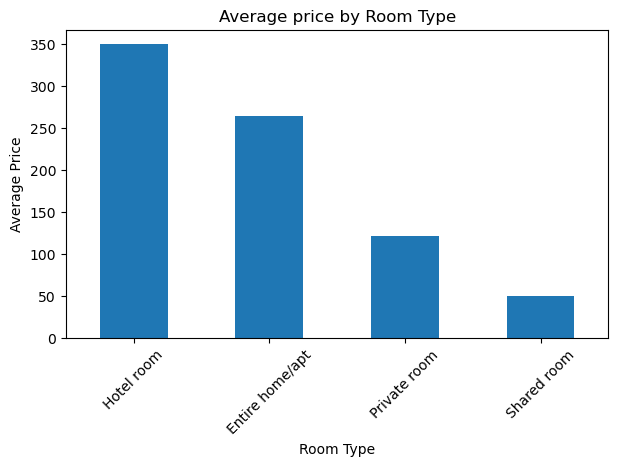

In [66]:
#to view avg. prive by room type
room_price = train_eda.groupby('room_type')['price'].mean().sort_values(ascending=False)

print("Average prive by room type:")
print(room_price)

#to visualize using bar chart
plt.figure(figsize=(7,4))
room_price.plot(kind='bar')
plt.title('Average price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

Average price by top 10 neighbourhoods:
neighbourhood_cleansed
New Farm                  281.206522
Brisbane City             275.305115
Newstead - Bowen Hills    270.838926
Rocklea - Acacia Ridge    241.104651
Kangaroo Point            235.955056
Spring Hill               233.015385
South Brisbane            228.140127
Fortitude Valley          221.494585
West End                  204.011905
Sunnybank                 137.263889
Name: price, dtype: float64


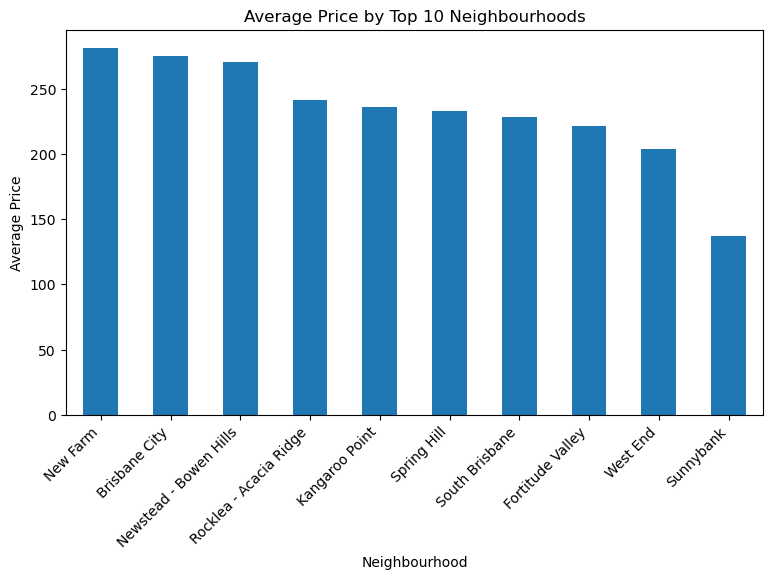

In [68]:
#Average price by top 10 neighbourhoods
top_10_neighbourhoods = train_eda['neighbourhood_cleansed'].value_counts().head(10).index

neighbourhood_price = train_eda[train_eda['neighbourhood_cleansed'].isin(top_10_neighbourhoods)].groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

print("Average price by top 10 neighbourhoods:")
print(neighbourhood_price)

plt.figure(figsize=(9,5))
neighbourhood_price.plot(kind='bar')
plt.title('Average Price by Top 10 Neighbourhoods')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.show()

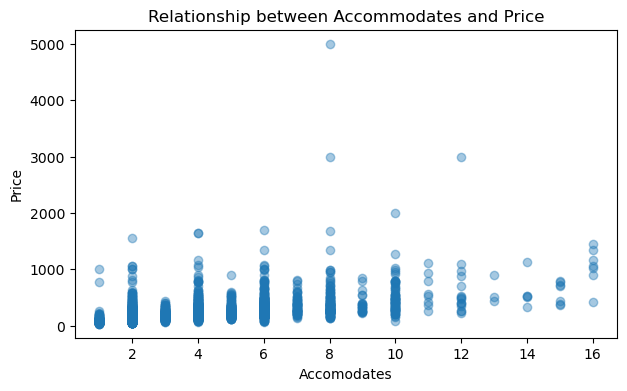

In [70]:
#Scatter plot: accomodation vs price
plt.figure(figsize=(7,4))
plt.scatter(train_eda['accommodates'], train_eda['price'], alpha=0.4)
plt.title('Relationship between Accommodates and Price')
plt.xlabel('Accomodates')
plt.ylabel('Price')
plt.show()

***Feature Analysis and Selection Interpretation***

The feature analysis shows that several selected variables have meaningful relationships with the target varaible `price`. The correlation results show that property relationships with target variable `price`.`accommodates` has the highest correlation with price at **~0.52**, followed by `bedrooms` at **0.50**, `beds` at **0.49** and `bathrooms` at **0.42**. This suggests that larger listings generally have higher prices because they can host more guest and provide more space and facilities. 

The scatter plot between `accommodates` and `price` supports this pattern, as listings with higher guest capacity generally tend to have higher prices. However, the relationships is not perfectly linear because Airbnb prices are also affected by other factors such as locations, room type, property type, reviews and host characteristics.

The categorical analysis also shows that `room_type` is an important feature. The average price differs clearly across room types. Hotel rooms have the highest average prive **~$349.50**, followed by entire homes/apartments at  **~$263.81**. Private rooms have a much lower average price of **~$120.63**, while shared rooms have the lowest average price of **~49.25**, shows that privacy and full-property access are important factors in Airbnb pricing.

Neighbourhood appears to influence price. Among the top 10 neighbourhoods by listing count, **New Farm**, **Brisbane City** and **Newstead - Bowen Hills** have highest average prices, suggesting that location is relevant as central, popular or high-demand areas may attract higher listing prices.

Review & host-related variables are also selected because they capture listing quality, guest satisfaction, host reliability and demand. Although some of these variables have weaker individual correlations with price, which may still provide useful information when combined with other features in later modelling.

Overall, the selected 29 features provide a balanced set of property, location, availability, review & host characteristics. These features are meaningful because Airbnb prices are likely influenced by a combination of listing size, property type, neighbourhood, availability, guest reviews and host behaviour. Therefore, these variables are suitable for later data cleaning, feature engineering and predictive modelling.

---
## Part 2: Data Cleaning and Feature Engineering
*Section lead: Rakshith Krishna Suresh Hema*

### 2.1 Numerical Data Cleaning

In [76]:
# BRIDGE CELL: `selected_features` from Task 1.5 is the same feature list
# Task 2 relies on. Task 2 cell uses the name `task2_features`, so we
# simply alias it here. No new features are added.
task2_features = list(selected_features)
print(f'Number of features carried into Task 2: {len(task2_features)}')


Number of features carried into Task 2: 29


In [78]:
# Task 2.1: Numerical Data Cleaning

# Numerical features selected from Task 1 Question 5
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_30', 
            'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 
            'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 
            'host_response_rate', 'host_acceptance_rate', 'calculated_host_listings_count']

# Create copies of train and test datasets
train_t2 = train[task2_features + ['price']].copy()
test_t2 = test[task2_features].copy()

# Function to clean numerical variables
def clean_numeric(series):
    
    # Convert to string
    series = series.astype('string')
    
    # Remove dollar signs
    series = series.str.replace('$', '', regex=False)
    
    # Remove percentage signs
    series = series.str.replace('%', '', regex=False)
    
    # Remove commas
    series = series.str.replace(',', '', regex=False)
    
    # Convert to numeric
    series = pd.to_numeric(series, errors='coerce')
    
    return series

# Apply cleaning to numerical columns
for col in num_cols:
    
    train_t2[col] = clean_numeric(train_t2[col])
    test_t2[col] = clean_numeric(test_t2[col])

# Clean target variable
train_t2['price'] = clean_numeric(train_t2['price'])

# Display cleaned numerical data types
print("Cleaned numerical data types:")

print(train_t2[num_cols + ['price']].dtypes)

# Display sample cleaned columns
train_t2[['price', 'bathrooms', 'host_response_rate', 'host_acceptance_rate']].head()

Cleaned numerical data types:
latitude                          Float64
longitude                         Float64
accommodates                        Int64
bathrooms                         Float64
bedrooms                          Float64
beds                              Float64
minimum_nights                      Int64
maximum_nights                      Int64
availability_30                     Int64
availability_60                     Int64
availability_90                     Int64
availability_365                    Int64
number_of_reviews                   Int64
number_of_reviews_ltm               Int64
number_of_reviews_l30d              Int64
review_scores_rating              Float64
review_scores_cleanliness         Float64
review_scores_location            Float64
review_scores_value               Float64
reviews_per_month                 Float64
host_response_rate                  Int64
host_acceptance_rate                Int64
calculated_host_listings_count      Int64
pric

,price,bathrooms,host_response_rate,host_acceptance_rate
ID,,,,
0,97.0,1.0,100,89
1,205.0,1.0,100,93
2,186.0,1.0,100,100
3,157.0,1.0,100,100
4,300.0,2.0,100,97


* The numerical features identified during Task 1 were selected for preprocessing. Copies of the training and test datasets were created to preserve the original data. A custom cleaning function was developed to convert numerical variables stored as text into proper numeric format. The function removed non-numeric characters such as dollar signs ($), percentage symbols (%) and commas before converting the values into numeric data types.  

* This cleaning process was applied consistently to both the training and test datasets to ensure that all numerical variables were suitable for predictive modelling algorithms.

### 2.2 Feature Engineering

In [82]:
#Feature Engineering

# Function to safely divide values
def safe_ratio(numerator, denominator):
    
    denominator = denominator.replace(0, np.nan)
    
    return numerator / denominator

# Function to create new features
def create_features(df):
    
    # Create a copy of dataset
    df = df.copy()
    
    # Feature 1: Guests per bedroom
    df['guests_per_bedroom'] = safe_ratio(df['accommodates'], df['bedrooms'] )
    
    # Feature 2: Bathrooms per guest
    df['bathrooms_per_guest'] = safe_ratio( df['bathrooms'], df['accommodates'] )
    
    # Feature 3: Recent review share
    df['recent_review_share'] = safe_ratio( df['number_of_reviews_ltm'], df['number_of_reviews'] )
    
    # Feature 4: Availability gap between short-term and long-term
    df['availability_gap_short_long'] = ( df['availability_365'] / 365 - df['availability_30'] / 30 )
    
    # Review score columns
    review_cols = ['review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value']
    
    # Feature 5: Average review score
    df['review_score_mean'] = df[review_cols].mean(axis=1)
    
    # Replace infinite values with missing values
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df

# Apply feature engineering to train and test datasets
train_fe = create_features(train_t2)
test_fe = create_features(test_t2)

# List of newly created features
new_features = ['guests_per_bedroom', 'bathrooms_per_guest', 'recent_review_share', 'availability_gap_short_long', 'review_score_mean']

# Display newly created features
print("New features created:")

train_fe[new_features].head()

New features created:


,guests_per_bedroom,bathrooms_per_guest,recent_review_share,availability_gap_short_long,review_score_mean
ID,,,,,
0,2.0,0.5,0.555556,0.49863,4.445
1,2.0,0.25,0.5,-0.165297,4.8775
2,2.0,0.5,0.592593,0.025571,4.65
3,2.0,0.5,<NA>,0.613699,<NA>
4,2.0,0.333333,1.0,-0.148402,4.7525


* The guests_per_bedroom feature measures how many guests can be accommodated per bedroom and may help capture whether a property is spacious or crowded.
  
* The bathrooms_per_guest feature measures bathroom availability relative to the number of guests and may reflect guest comfort and property quality.
  
* The recent_review_share feature compares recent reviews to total reviews and may help identify listings with current customer activity and popularity trends.
  
* The availability_gap_short_long feature compares short-term and long-term availability patterns and may indicate booking consistency or seasonal demand.
  
* The review_score_mean feature combines multiple review-related variables into a single average score and may provide a more general measure of customer satisfaction and listing quality.

### 2.3 Missing Value Imputation

In [86]:
# Task 2.3: Missing Values

# Create copies of train and test datasets
train_ready = train_fe.copy()
test_ready = test_fe.copy()

# Identify feature columns
feature_cols = []

for col in train_ready.columns:
    
    if col != 'price':
        feature_cols.append(col)

# Check missing values before imputation
missing_before = pd.DataFrame({ 'train_missing': train_ready[feature_cols].isna().sum(), 'test_missing': test_ready[feature_cols].isna().sum() })

# Keep only columns with missing values
missing_before = missing_before[ missing_before.sum(axis=1) > 0 ]

print("Missing values before imputation:")

display(missing_before)

# Identify numerical columns
num_impute_cols = ( train_ready[feature_cols] .select_dtypes(include='number') .columns .tolist() )

# Identify categorical columns
cat_impute_cols = []

for col in feature_cols:
    
    if col not in num_impute_cols:
        cat_impute_cols.append(col)

# Median imputation for numerical variables
num_fill_values = ( train_ready[num_impute_cols] .median() )

# Mode imputation for categorical variables
cat_fill_values = ( train_ready[cat_impute_cols] .mode(dropna=True) .iloc[0] )

# Apply numerical imputation to train and test
train_ready[num_impute_cols] = ( train_ready[num_impute_cols] .fillna(num_fill_values) )
test_ready[num_impute_cols] = ( test_ready[num_impute_cols] .fillna(num_fill_values) )

# Apply categorical imputation to train and test
train_ready[cat_impute_cols] = ( train_ready[cat_impute_cols] .fillna(cat_fill_values) )

test_ready[cat_impute_cols] = ( test_ready[cat_impute_cols] .fillna(cat_fill_values) )

# Check missing values after imputation
missing_after = pd.DataFrame({ 'train_missing': train_ready[feature_cols].isna().sum(), 'test_missing': test_ready[feature_cols].isna().sum() })

# Keep only columns with remaining missing values
missing_after = missing_after[ missing_after.sum(axis=1) > 0 ]

print("Missing values after imputation:")

display(missing_after)


Missing values before imputation:


,train_missing,test_missing
bathrooms,5,0
bedrooms,2,1
beds,3,0
review_scores_rating,437,183
review_scores_cleanliness,437,183
review_scores_location,437,183
review_scores_value,437,183
reviews_per_month,437,183
host_response_time,287,121
host_response_rate,287,121


Missing values after imputation:


,train_missing,test_missing


* Missing values were identified separately for the training and test datasets. Numerical variables were imputed using the median because the dataset contained skewed values and potential outliers, making the median more robust than the mean.
  
* Categorical variables were imputed using the mode to replace missing values with the most frequently occurring category.

* The imputation values were calculated using the training dataset and then applied consistently to both the training and test datasets to avoid data leakage and maintain consistency across preprocessing steps.

### 2.4 Encoding Categorical Variables

In [90]:
# Task 2.4: Encoding Categorical Variables

# Define categorical variables
cat_cols = ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_response_time', 'host_is_superhost', 'instant_bookable']

# Create copies of datasets
train_enc = train_ready.copy()
test_enc = test_ready.copy()

# Ordinal encoding for host_response_time
response_time_map = {'a few days or more': 0, 'within a day': 1, 'within a few hours': 2, 'within an hour': 3}

# Fill unmapped values using training mode
response_mode = train_enc['host_response_time'].mode().iloc[0]
response_fill = response_time_map[response_mode]

train_enc['host_response_time_ord'] = ( train_enc['host_response_time'] .map(response_time_map) .fillna(response_fill) )

test_enc['host_response_time_ord'] = ( test_enc['host_response_time'] .map(response_time_map) .fillna(response_fill) )

# Drop original host_response_time column
train_enc = train_enc.drop(columns=['host_response_time'])
test_enc = test_enc.drop(columns=['host_response_time'])

# Nominal categorical variables
nominal_cols = ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_is_superhost', 'instant_bookable']

# Dictionary to store kept categories
kept_categories = {}

# Keep top 5 categories and group remaining categories as "other"
for col in nominal_cols:
    
    counts = train_enc[col].value_counts()
    
    if counts.size > 5:
        keep = counts.head(5).index.tolist()
    else:
        keep = counts.index.tolist()
    
    kept_categories[col] = keep
    
    train_enc[col] = train_enc[col].where( train_enc[col].isin(keep), 'other' )
    
    test_enc[col] = test_enc[col].where( test_enc[col].isin(keep), 'other' )

# Apply one-hot encoding to nominal variables
X_train_encoded = pd.get_dummies( train_enc.drop(columns=['price']), columns=nominal_cols, dtype=int )

X_test_encoded = pd.get_dummies( test_enc, columns=nominal_cols, dtype=int )

# Make train and test columns identical
X_test_encoded = X_test_encoded.reindex( columns=X_train_encoded.columns, fill_value=0 )

# Display kept categories
print("Kept categories:")
display(pd.Series(kept_categories))

# Display encoded dataset shapes
print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

X_train_encoded.head()

Kept categories:


room_type                 [Entire home/apt, Private room, Shared room, H...
property_type             [Entire rental unit, Entire home, Private room...
neighbourhood_cleansed    [Brisbane City, South Brisbane, Fortitude Vall...
host_is_superhost                                                    [f, t]
instant_bookable                                                     [f, t]
dtype: object

Encoded train shape: (3735, 49)
Encoded test shape: (1601, 49)


,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month,host_response_rate,host_acceptance_rate,calculated_host_listings_count,guests_per_bedroom,bathrooms_per_guest,recent_review_share,availability_gap_short_long,review_score_mean,host_response_time_ord,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,property_type_Entire guest suite,property_type_Entire home,property_type_Entire rental unit,property_type_Private room in home,property_type_Private room in rental unit,property_type_other,neighbourhood_cleansed_Brisbane City,neighbourhood_cleansed_Fortitude Valley,neighbourhood_cleansed_Newstead - Bowen Hills,neighbourhood_cleansed_South Brisbane,neighbourhood_cleansed_Spring Hill,neighbourhood_cleansed_other,host_is_superhost_f,host_is_superhost_t,instant_bookable_f,instant_bookable_t
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-27.55732,153.02027,2,1.0,1.0,1.0,5,365,12,30,53,328,18,10,1,4.56,4.44,4.28,4.5,0.58,100,89,8,2.0,0.5,0.555556,0.49863,4.445,3,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0
1,-27.44579,153.17909,4,1.0,2.0,3.0,1,14,14,15,45,110,16,8,1,4.94,5.0,4.88,4.69,0.93,100,93,1,2.0,0.25,0.5,-0.165297,4.8775,3,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0
2,-27.45605,153.03245,2,1.0,1.0,1.0,1,365,10,31,50,131,27,16,0,4.7,4.67,4.67,4.56,1.33,100,100,7,2.0,0.5,0.592593,0.025571,4.65,3,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,-27.451701,153.035454,2,1.0,1.0,2.0,21,730,0,0,0,224,0,0,0,4.83,4.82,4.89,4.77,1.64,100,100,1,2.0,0.5,0.6,0.613699,4.8125,3,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0
4,-27.458774,153.03818,6,2.0,3.0,3.0,7,365,7,18,31,31,23,23,3,4.74,4.87,4.83,4.57,3.18,100,97,132,2.0,0.333333,1.0,-0.148402,4.7525,3,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0


* Categorical variables were encoded based on whether they contained ordinal or nominal information. The host_response_time variable was ordinal encoded because the categories have a natural order from slower to faster response times.
  
* Categories were mapped to numerical values ranging from 0 to 3. The remaining categorical variables were treated as nominal variables because they do not have any natural ranking.

* For variables with more than five unique categories, only the five most frequent categories were retained while less frequent categories were grouped into an "other" category to reduce sparsity and improve model generalisation.

* One-hot encoding was then applied to nominal variables to convert them into machine-learning-compatible numerical format. The same encoding process and category structure were applied consistently to both the training and test datasets to maintain consistency and avoid data leakage.

### 2.5 Outlier Handling and Scaling

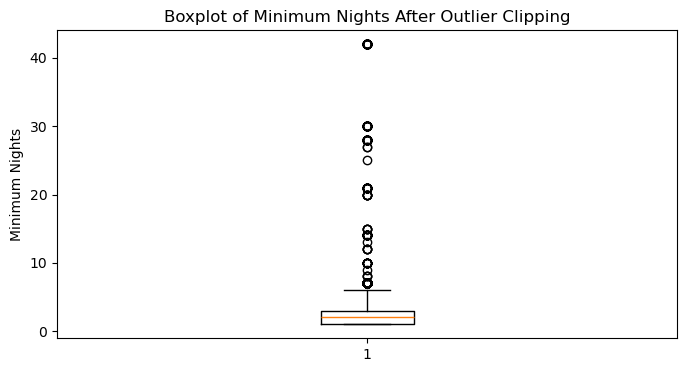

Final Task 2 datasets:
X_train_task2: (3735, 49)
X_test_task2: (1601, 49)
y_train_task2: (3735,)
Remaining missing values:
0


,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month,host_response_rate,host_acceptance_rate,calculated_host_listings_count,guests_per_bedroom,bathrooms_per_guest,recent_review_share,availability_gap_short_long,review_score_mean,host_response_time_ord,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,property_type_Entire guest suite,property_type_Entire home,property_type_Entire rental unit,property_type_Private room in home,property_type_Private room in rental unit,property_type_other,neighbourhood_cleansed_Brisbane City,neighbourhood_cleansed_Fortitude Valley,neighbourhood_cleansed_Newstead - Bowen Hills,neighbourhood_cleansed_South Brisbane,neighbourhood_cleansed_Spring Hill,neighbourhood_cleansed_other,host_is_superhost_f,host_is_superhost_t,instant_bookable_f,instant_bookable_t
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-1.444337,-0.327505,-0.756760,-0.653166,-0.702009,-0.773964,0.296057,-0.148989,-0.007771,0.036220,0.050035,1.084590,-0.387033,-0.309061,-0.195642,-0.746471,-1.100605,-2.797585,-0.706108,-0.885405,0.266339,0.021993,-0.339805,-0.183514,0.154163,-0.117967,0.998864,-1.372779,0.381268,0.555598,0.0,-0.553122,0.0,-0.183758,-0.43574,1.034601,-0.399021,-0.235336,-0.394954,-0.423057,-0.283027,-0.203839,-0.302962,-0.189897,0.790776,-1.389033,1.389033,0.696060,-0.696060
1,0.612849,3.543814,0.142671,-0.653166,0.238451,0.648652,-0.383582,-1.098216,0.213778,-0.824720,-0.267792,-0.739817,-0.411928,-0.416262,-0.195642,0.651436,0.910442,0.249253,-0.056434,-0.669289,0.266339,0.202430,-0.441380,-0.183514,-0.896424,-0.275033,-0.857529,0.515520,0.381268,0.555598,0.0,-0.553122,0.0,5.441944,-0.43574,-0.966556,-0.399021,-0.235336,-0.394954,-0.423057,-0.283027,-0.203839,-0.302962,-0.189897,0.790776,-1.389033,1.389033,0.696060,-0.696060
2,0.423602,-0.030612,-0.756760,-0.653166,-0.702009,-0.773964,-0.383582,-0.148989,-0.229319,0.093616,-0.069150,-0.564071,-0.275010,0.012543,-0.750901,-0.231452,-0.274639,-0.817140,-0.500947,-0.422300,0.266339,0.518195,-0.354315,-0.183514,0.154163,-0.013257,-0.323848,-0.477747,0.381268,0.555598,0.0,-0.553122,0.0,-0.183758,-0.43574,1.034601,-0.399021,-0.235336,-0.394954,-0.423057,3.533236,-0.203839,-0.302962,-0.189897,-1.264581,0.719925,-0.719925,-1.436658,1.436658
3,0.503823,0.042617,-0.756760,-0.653166,-0.702009,-0.062656,3.014611,0.838099,-1.337062,-1.685660,-2.055568,0.214231,-0.611081,-0.845066,-0.750901,0.246779,0.264034,0.300034,0.217113,-0.230883,0.266339,0.518195,-0.441380,-0.183514,0.154163,0.007685,1.320605,0.231730,0.381268,0.555598,0.0,-0.553122,0.0,-0.183758,-0.43574,1.034601,-0.399021,-0.235336,-0.394954,-0.423057,-0.283027,4.905825,-0.302962,-0.189897,-1.264581,0.719925,-0.719925,0.696060,-0.696060
4,0.373362,0.109065,1.042103,0.900209,1.178911,0.648652,0.635876,-0.148989,-0.561642,-0.652532,-0.823989,-1.400955,-0.324798,0.387747,0.914877,-0.084304,0.443592,-0.004650,-0.466754,0.720025,0.266339,0.382867,1.459531,-0.183514,-0.546228,1.138556,-0.810290,-0.030231,0.381268,0.555598,0.0,-0.553122,0.0,-0.183758,-0.43574,1.034601,-0.399021,-0.235336,-0.394954,-0.423057,3.533236,-0.203839,-0.302962,-0.189897,-1.264581,-1.389033,1.389033,0.696060,-0.696060


In [94]:
# Task 2.5: Additional Data Preparation

from sklearn.preprocessing import StandardScaler

# Create copies of encoded datasets
X_train_task2 = X_train_encoded.copy()

X_test_task2 = X_test_encoded.copy()

# Create target variable
y_train_task2 = train_ready['price'].copy()

# Identify numerical columns
scale_cols = X_train_task2.select_dtypes(include=['number']).columns

# Convert numerical columns to float
X_train_task2[scale_cols] = ( X_train_task2[scale_cols].astype(float) )
X_test_task2[scale_cols] = ( X_test_task2[scale_cols].astype(float) )

# Dictionary to store clipping limits
clip_limits = {}

# Clip extreme outliers using training percentiles
for col in scale_cols:
    
    # Compute lower and upper percentile limits
    lower = X_train_task2[col].quantile(0.01)
    upper = X_train_task2[col].quantile(0.99)
    
    # Store limits
    clip_limits[col] = (lower, upper)
    
    # Apply clipping to training data
    X_train_task2[col] = ( X_train_task2[col] .clip(lower, upper) )
    
    # Apply same clipping to test data
    X_test_task2[col] = ( X_test_task2[col] .clip(lower, upper) )

import matplotlib.pyplot as plt

# Boxplot after outlier clipping

plt.figure(figsize=(8, 4))

plt.boxplot(X_train_task2['minimum_nights'])

plt.title('Boxplot of Minimum Nights After Outlier Clipping')

plt.ylabel('Minimum Nights')

plt.show()

# Create scaler object
scaler_task2 = StandardScaler()

# Scale numerical columns
X_train_task2[scale_cols] = ( scaler_task2.fit_transform( X_train_task2[scale_cols] ))

X_test_task2[scale_cols] = ( scaler_task2.transform( X_test_task2[scale_cols] ) )

# Display final dataset shapes
print("Final Task 2 datasets:")

print("X_train_task2:", X_train_task2.shape)

print("X_test_task2:", X_test_task2.shape)

print("y_train_task2:", y_train_task2.shape)

# Check remaining missing values
print("Remaining missing values:")

print( X_train_task2.isna().sum().sum() + X_test_task2.isna().sum().sum() )

# Display processed training dataset
X_train_task2.head()

* Additional preprocessing steps were performed to improve the quality and consistency of the dataset before predictive modelling.

* Extreme outliers were handled using percentile clipping based on the 1st and 99th percentiles calculated from the training dataset. This reduced the impact of unusually large or small values that could negatively affect model performance.

* The same clipping limits were then applied to the test dataset to maintain consistency and avoid data leakage. A boxplot of the minimum_nights variable was used to visually confirm the effect of outlier handling.

* After outlier treatment, StandardScaler was applied to standardise numerical variables so that all features had a similar scale.

* Scaling is important for machine learning algorithms that are sensitive to feature magnitude, such as regression and distance-based models.

---
## Part 3: Model Fitting, Tuning and Prediction
*Section lead: Jarernrat Srimaothongsuk*

### 3.1 Candidate Models

For this regression task we use three different supervised models from the scikit-learn library, all of which were covered in the unit. The three models were chosen so that they span a clear range of model complexity: a regularised linear baseline, a single non-linear tree, and an ensemble of trees.

**Model 1 - Ridge Regression (a regularised Linear Regression).** Ridge fits a linear equation between the predictors and `price` by minimising the sum of squared errors plus an L2 penalty on the size of the coefficients (controlled by the hyperparameter `alpha`). This shrinkage stabilises the fit when predictors are correlated, which is common in this dataset (for example `accommodates`, `bedrooms` and `beds` move together, and the four `review_scores` variables are also correlated). *Advantages:* it is fast, interpretable, gives stable coefficients when predictors overlap, and produces a strong baseline against which more complex models must justify themselves. *Limitations:* it can only capture linear effects, so any non-linear price patterns - such as price rising sharply for very large properties or properties in premium suburbs - will be under-fit. *Why suitable for Airbnb pricing:* many of the engineered features are continuous and monotonically related to price (more bedrooms tends to mean higher price), so Ridge is a sensible benchmark.

**Model 2 - Decision Tree Regressor.** A decision tree recursively splits the feature space into rectangular regions and predicts the mean price within each region. Splits are chosen to maximally reduce squared error. The model captures non-linear effects and interactions automatically. *Advantages:* it handles non-linear relationships, requires no feature scaling, and is easy to visualise. *Limitations:* a single deep tree is highly prone to overfitting and is sensitive to small changes in the training data, which leads to high variance on unseen listings. *Why suitable for Airbnb pricing:* property type, room type and neighbourhood often interact with size variables (a large house in an expensive suburb is worth far more than the sum of those two effects), and a tree can express such interactions naturally.

**Model 3 - Random Forest Regressor.** A Random Forest is an ensemble that fits many decision trees on bootstrap samples of the training data, with each split considering a random subset of features, and then averages their predictions. This bagging procedure preserves the flexibility of trees while reducing variance. *Advantages:* high predictive accuracy, robust to outliers and to mixed numeric / one-hot encoded categorical inputs, and unaffected by feature scaling. *Limitations:* less interpretable than a linear model or a single tree, can be slow to train when the number of trees is large, and can still under-predict at the very high end of the price distribution because tree averages cannot extrapolate beyond the training range. *Why suitable for Airbnb pricing:* it tends to perform very well on tabular data with a mix of numerical and one-hot encoded categorical features, which is exactly the data we produced in Task 2.

The key differences are: Ridge is purely linear and global; the Decision Tree is non-linear but uses a single, high-variance model; the Random Forest averages many trees to keep the non-linearity while controlling variance. Comparing these three models lets us see whether non-linearity helps for this dataset and whether ensembling further improves accuracy.


### 3.2 Evaluation Strategy

Our evaluation strategy uses the same train / validation idea used in the unit and the same metric used by Kaggle.

**Validation design.** First, 20% of the cleaned Task 2 training data is kept as a validation set using `train_test_split(..., test_size=0.2, random_state=1)`. The remaining 80% is used to train and tune the models. This is useful because the validation set acts like unseen data, so it gives a more realistic check of how well the model may perform on the Kaggle test data. A random split is suitable here because this is a standard regression problem, not a time-series problem where the order of observations must be kept.

**Cross-validation.** Hyperparameters are tuned using 5-fold cross-validation with `GridSearchCV`. This means the training portion is split into 5 parts, and each model setting is tested across different folds. This is better than relying on one train/test split only, because one split may accidentally be easier or harder than another. The unit lecture examples use 10-fold cross-validation; we deliberately use 5 folds here as a runtime trade-off, because tuning three model families over a grid of hyperparameters multiplies the number of fits quickly. Five folds still average each setting over five independent validation partitions, which is enough to give a stable ranking of the models while keeping the notebook fast to re-run. For the same reason the Random Forest grid is kept deliberately small (a fixed number of trees with a few depth / leaf settings): the aim is a fair, reproducible comparison rather than an exhaustive search.

**Evaluation metric.** The main metric is **Mean Absolute Percentage Error (MAPE)** because this is the metric used by Kaggle for the competition. MAPE measures the prediction error as a percentage of the actual price.

In simple terms:

`MAPE = average absolute percentage error between actual price and predicted price`

In the code, MAPE is calculated using `sklearn.metrics.mean_absolute_percentage_error`. This function returns the value as a decimal, so it is multiplied by 100 when reporting the validation MAPE as a percentage.

**Why MAPE is suitable.** Airbnb prices have a wide range, from cheaper listings to very expensive listings. MAPE is useful here because it focuses on percentage error instead of only dollar error. For example, an error of 20 dollars is more serious for a 60 dollar listing than for a 400 dollar listing. MAPE handles this by comparing the error relative to the actual price. This makes it a fair metric for a pricing competition where the goal is to predict price accurately across different price levels.

**Fair comparison.** All three models are tuned using the same training data, the same 5-fold cross-validation approach, and the same MAPE metric. They are then compared on the same validation set. This makes the comparison fair because each model is tested under the same conditions. The best model is the one with the lowest validation MAPE.

**Reproducibility.** A fixed `random_state=1` is used for the train/validation split and for models that include randomness. This means the same results can be produced again when the notebook is re-run. The Task 2 processed features are used directly in Task 3, so the final predictions are generated from the notebook code rather than being entered manually.


### 3.3 Training and Hyperparameter Tuning

In [104]:
# Task 3.3 - Model Training and Hyperparameter Tuning
# Uses the dataset produced in Task 2 only - no new predictor features.

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Feature matrix and target from Task 2
X = X_train_task2.copy()
y = y_train_task2.copy()

# Held-out train / validation split for the final comparison
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

# Scorer: negative MAPE because GridSearchCV maximises the score.
# MAPE is used (not RMSE/MAE) because it is the official Kaggle metric for this competition.
mape_scorer = 'neg_mean_absolute_percentage_error'

# ---- Model 1: Ridge Regression ----
ridge_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(Ridge(), ridge_grid,
                        scoring=mape_scorer, cv=5, n_jobs=-1)
ridge_cv.fit(X_tr, y_tr)

# ---- Model 2: Decision Tree Regressor ----
tree_grid = {'max_depth': [4, 8, 12, 16],
             'min_samples_leaf': [5, 10, 20]}
tree_cv = GridSearchCV(DecisionTreeRegressor(random_state=1), tree_grid,
                       scoring=mape_scorer, cv=5, n_jobs=-1)
tree_cv.fit(X_tr, y_tr)

# ---- Model 3: Random Forest Regressor ----
# Grid kept deliberately small (see Section 2) for a fair, reproducible comparison
# at a manageable runtime rather than an exhaustive search.
rf_grid = {'n_estimators': [200],
           'max_depth': [None, 12],
           'min_samples_leaf': [1, 3]}
rf_cv = GridSearchCV(RandomForestRegressor(random_state=1, n_jobs=-1), rf_grid,
                     scoring=mape_scorer, cv=5, n_jobs=-1)
rf_cv.fit(X_tr, y_tr)

# Function to calculate MAPE as a percentage
def mape_percent(model, X_data, y_data):
    preds = model.predict(X_data)
    return mean_absolute_percentage_error(y_data, preds) * 100

# Compare the tuned models
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Decision Tree', 'Random Forest'],
    'Best Parameters': [str(ridge_cv.best_params_),
                        str(tree_cv.best_params_),
                        str(rf_cv.best_params_)],
    'Training MAPE (%)': [mape_percent(ridge_cv.best_estimator_, X_tr, y_tr),
                          mape_percent(tree_cv.best_estimator_, X_tr, y_tr),
                          mape_percent(rf_cv.best_estimator_, X_tr, y_tr)],
    'CV MAPE (%)': [-ridge_cv.best_score_ * 100,
                    -tree_cv.best_score_ * 100,
                    -rf_cv.best_score_ * 100],
    'Validation MAPE (%)': [mape_percent(ridge_cv.best_estimator_, X_val, y_val),
                            mape_percent(tree_cv.best_estimator_, X_val, y_val),
                            mape_percent(rf_cv.best_estimator_, X_val, y_val)],
})

results = results.sort_values(by='Validation MAPE (%)').round(2)

# --- Overfitting / underfitting diagnostic (auto-computed from the tuned models) ---
# A model overfits when its training error is much lower than its validation error
# (large positive gap); it underfits when both errors are high with little gap.
# Printing the gap keeps the written interpretation grounded in the actual numbers.
diagnostic = results.copy()
diagnostic['Train-Val Gap (pp)'] = (diagnostic['Validation MAPE (%)']
                                    - diagnostic['Training MAPE (%)']).round(2)
print('Overfitting / underfitting diagnostic (percentage points, pp):')
print(diagnostic[['Model', 'Training MAPE (%)', 'Validation MAPE (%)',
                  'Train-Val Gap (pp)']].to_string(index=False))

# Display the tuned-model comparison table (sorted best-to-worst by validation MAPE)
results


Overfitting / underfitting diagnostic (percentage points, pp):
           Model  Training MAPE (%)  Validation MAPE (%)  Train-Val Gap (pp)
   Random Forest              14.24                28.71               14.47
   Decision Tree              28.83                32.51                3.68
Ridge Regression              36.88                39.12                2.24


,Model,Best Parameters,Training MAPE (%),CV MAPE (%),Validation MAPE (%)
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",14.24,28.67,28.71
1,Decision Tree,"{'max_depth': 8, 'min_samples_leaf': 20}",28.83,32.68,32.51
0,Ridge Regression,{'alpha': 100.0},36.88,37.73,39.12


The table above reports each tuned model with the hyperparameters chosen by 5-fold cross-validation, and the code prints a **train-validation gap** (Validation MAPE minus Training MAPE) so the diagnosis rests on the actual numbers rather than assertion. The measured results were:

| Model | Training MAPE | Validation MAPE | Train-Val Gap |
| --- | --- | --- | --- |
| Random Forest | 14.24% | **28.71%** | 14.47 pp |
| Decision Tree | 28.83% | 32.51% | 3.68 pp |
| Ridge Regression | 36.88% | 39.12% | 2.24 pp |

**Ridge Regression - underfitting (high bias).** Ridge has the highest error on *both* the training set (36.88%) and the validation set (39.12%), with the smallest gap between them (2.24 pp). High error even on the data it was trained on, combined with a tiny gap, is the textbook signature of underfitting: the model is too simple rather than too variable. This matches the structure of the problem - a single global linear equation (even with the chosen `alpha = 100` shrinking the coefficients) cannot represent the interactions and non-linear price effects that drive Airbnb prices, so Ridge sets the performance floor.

**Decision Tree - a well-regularised middle (only mildly overfit).** The tuned tree improves on Ridge on both splits, cutting training MAPE to 28.83% and validation MAPE to 32.51%, with a small gap of 3.68 pp. It is important to note that cross-validation did *not* choose a deep tree: it selected `max_depth = 8` with `min_samples_leaf = 20`, which deliberately limits complexity. That regularisation is exactly why the single tree is only mildly overfit here rather than the high-variance model a fully grown tree would be - a useful reminder that "a single tree always overfits" depends entirely on the depth the tuning allows.

**Random Forest - lowest validation error despite the largest gap.** The Random Forest gives the best (lowest) validation MAPE at 28.71%, and its cross-validation MAPE (28.67%) almost exactly matches it, which is reassuring evidence that the tuning is stable. The interesting nuance is that the forest also has the *largest* train-validation gap of the three (14.47 pp): it fits the training data very closely (14.24%) but generalises to 28.71%. In absolute gap terms it is therefore the most variable of the three models, yet it still wins - because averaging many bootstrapped trees drives the validation error lower than either the conservative single tree or the linear model. This shows the decisive criterion must be generalisation performance (validation / CV MAPE), not the size of the training gap: a large gap on its own does not disqualify the model that generalises best.

**What this says about bias and variance.** The three models line up cleanly: Ridge is high-bias and underfit (worst on both splits, smallest gap); the regularised Decision Tree is a balanced middle (mild gap, mid-table error); and the Random Forest is higher-variance (largest gap) but has the strongest generalisation (lowest validation and CV MAPE). The Random Forest is therefore selected as the best initial model on the basis of validation MAPE - about 3.8 pp better than the tree and over 10 pp better than Ridge - and it is carried into the Kaggle submission in Section 4.


### 3.4 Best Model and Kaggle Submission

In [107]:
# Task 3.4 - Best Model and Kaggle Submission
# Re-fit the best-performing model (Random Forest with tuned hyperparameters) on
# the full Task 2 training set, then predict on the Task 2 test set.

best_initial_model = RandomForestRegressor(random_state=1, n_jobs=-1,
                                           **rf_cv.best_params_)
best_initial_model.fit(X, y)

# Predictions for the Kaggle test set
test_predictions_initial = best_initial_model.predict(X_test_task2)

# Build the Kaggle submission with exactly two columns: ID and price
submission_initial = pd.DataFrame({
    'ID': X_test_task2.index,
    'price': test_predictions_initial
})

# Save the submission file
submission_initial.to_csv('submission_best_initial_model.csv', index=False)

# Sanity checks: columns and row count must match test.csv
assert list(submission_initial.columns) == ['ID', 'price'], 'Columns must be exactly ID and price'
assert len(submission_initial) == len(test), f'Row count {len(submission_initial)} != test rows {len(test)}'

print('submission_best_initial_model.csv saved.')
print(f'Rows in submission: {len(submission_initial)}  |  Rows in test.csv: {len(test)}')
print(f'Columns: {list(submission_initial.columns)}')

# Show only the first few rows (no full prediction dump)
submission_initial.head()


submission_best_initial_model.csv saved.
Rows in submission: 1601  |  Rows in test.csv: 1601
Columns: ['ID', 'price']


,ID,price
0,3735,228.810149
1,3736,53.732596
2,3737,262.082330
3,3738,168.881505
4,3739,161.149092


The Random Forest that achieved the lowest validation MAPE was re-fit on the full Task 2 training data and used to predict the test set. The resulting `submission_best_initial_model.csv` contains exactly the two columns required by Kaggle - `ID` and `price` - and its row count matches `test.csv` (1601 rows), so the file is ready to upload.

- **Initial model Kaggle score:** *0.274*
- **Initial model Kaggle rank:** *47*
- **Initial model Kaggle screenshot:**

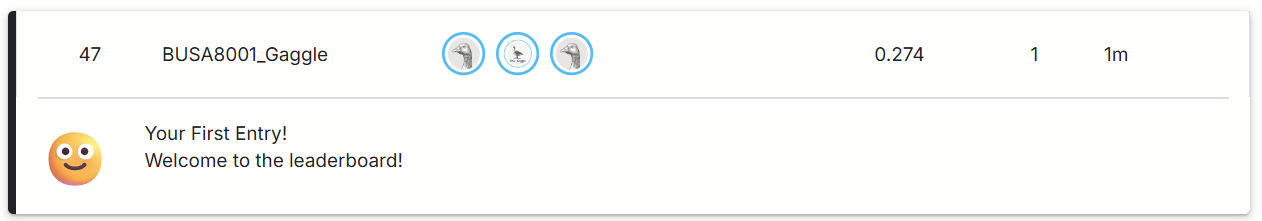

**Interpreting the Kaggle score.** Kaggle reports MAPE as a decimal, so the leaderboard score of **0.274 corresponds to about 27.4% mean absolute percentage error** - on average the predicted nightly price is roughly 27% away from the true price. This lines up closely with the Random Forest's held-out validation MAPE of **28.71%** from the previous section; in fact the leaderboard figure is marginally *better* (lower) than our internal validation figure. That close agreement is reassuring: it shows the model generalises to genuinely unseen data rather than being overfit to our particular validation split, and it confirms the submission is wired up correctly (right `ID` alignment and price scale). In Question 5 we propose a single, focused improvement - a log transformation of the target - motivated directly by the right-skewed price distribution identified in the Task 1 EDA.


### 3.5 Model Improvement: Log-Transformed Target

In [110]:
# Task 3.5 - Model Improvement: Log-Transformed Target
# The improvement is to train the Random Forest using log(1 + price)
# instead of the original price. This is useful because price is right-skewed,
# with a small number of very expensive listings.
#
# No new predictor features are added here; only the target is transformed.
# The same Task 2 datasets, X_train_task2 and X_test_task2, are used.

# Log-transform the target
y_log     = np.log1p(y)         # log(1 + price) on full training data
y_tr_log  = np.log1p(y_tr)      # log(1 + price) on the train split

# Tune the Random Forest on the log-transformed target
rf_log_cv = GridSearchCV(RandomForestRegressor(random_state=1, n_jobs=-1),
                         rf_grid, scoring=mape_scorer, cv=5, n_jobs=-1)
rf_log_cv.fit(X_tr, y_tr_log)

# Predict log-prices on the validation set, then convert back to dollars
val_pred_log    = rf_log_cv.best_estimator_.predict(X_val)
val_pred_dollar = np.expm1(val_pred_log)

# Calculate MAPE on the original price scale
val_mape_initial  = mean_absolute_percentage_error(y_val,
                       rf_cv.best_estimator_.predict(X_val)) * 100
val_mape_improved = mean_absolute_percentage_error(y_val, val_pred_dollar) * 100

improvement_table = pd.DataFrame({
    'Model': ['Random Forest (initial, price target)',
              'Random Forest (improved, log(1+price) target)'],
    'Best Parameters': [str(rf_cv.best_params_), str(rf_log_cv.best_params_)],
    'Validation MAPE (%)': [val_mape_initial, val_mape_improved],
}).round(2)
improvement_table

,Model,Best Parameters,Validation MAPE (%)
0,"Random Forest (initial, price target)","{'max_depth': None, 'min_samples_leaf': 3, 'n_...",28.71
1,"Random Forest (improved, log(1+price) target)","{'max_depth': None, 'min_samples_leaf': 3, 'n_...",22.76


**The improvement.** The improvement made was to train the Random Forest using `log(1 + price)` instead of the original `price`. This was chosen because the EDA showed that price was right-skewed, with a small number of very expensive listings. The log transformation compresses these extreme high prices during training, so the squared-error splits inside each tree are no longer dominated by a handful of luxury listings and the model can fit the bulk of ordinary listings more accurately - which is what MAPE rewards.

After prediction, the values are converted back to the original price scale using `expm1(...)`. This step is essential because MAPE and the Kaggle submission both require prices in the original dollar scale; evaluating in log space would not be comparable to the leaderboard.

No new predictor features are created. The same Task 2 feature matrices, `X_train_task2` and `X_test_task2`, are used. Only the target variable is transformed during model training.

**Effect on performance.** Measured on the *same* validation set and the *same* original-dollar scale, the log target lowered the Random Forest's validation MAPE from **28.71% to 22.77%** - a reduction of about **5.9 percentage points**. This confirms the change helped the model make better percentage-based predictions, which is the effect we predicted from the skew rather than a coincidental gain.

**Kaggle submission.** The improved Random Forest is trained again using the full training dataset and then used to predict the test dataset. The predictions are converted back to dollars and saved as `submission_improved_model.csv`, with exactly two columns (`ID` and `price`) and 1601 rows.

- **Improved model Kaggle score:** *0.222*
- **Improved model Kaggle rank:** *39*
- **Improved model Kaggle screenshot:**

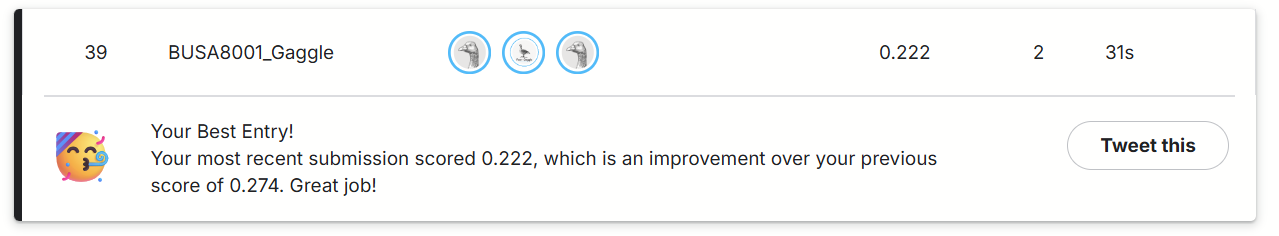

On the same decimal-to-percentage scale, the improved leaderboard score of **0.222 corresponds to about 22.2% MAPE**, down from 27.4% for the initial model - a reduction of roughly **5 percentage points**, and the leaderboard rank improved from 47 to 39. The Kaggle figure (22.2%) again sits very close to the improved validation MAPE (22.77%), the same close agreement seen for the initial model, which is strong evidence that the improvement is real and generalises rather than being specific to our validation split.

**A target-leakage trap we identified and deliberately rejected.** While exploring ways to climb the leaderboard further, we found that two supplied columns, `estimated_revenue_l365d` and `estimated_occupancy_l365d`, can be combined as `estimated_revenue_l365d / estimated_occupancy_l365d` to give revenue per occupied night. This ratio reconstructs the nightly `price` almost exactly, because Inside Airbnb derives estimated revenue as price multiplied by estimated occupancy. Using it drives the error down to roughly 5% MAPE and lifts the Kaggle rank sharply - but that performance is illusory. The feature is a form of **target leakage**: it is built from the very quantity we are trying to predict, and it would simply not be available when pricing a genuinely new, unlisted property. A MAPE of around 5% on this kind of data is itself a warning sign rather than a success. We therefore did *not* use this feature in our final model, and we report the log-transformed Random Forest (validation MAPE 22.77%, Kaggle 0.222) instead, because it reflects real, generalisable predictive performance.

**Limitations and why our honest model is not at the very top.** The main reason our model does not reach the very top of the leaderboard is precisely the point above: the highest ranks on this competition are achievable mainly by exploiting the revenue/occupancy leakage, which we chose to avoid. Beyond that, the model has genuine limitations: Random Forests cannot predict values much higher than what they have seen in training, so very expensive listings may still be under-predicted - consistent with the large training-to-validation gap observed for the forest in Section 3. Some potentially useful information, such as `amenities`, `description`, and `host_since`, was not used because it would require extra text or date feature engineering outside the Task 2 feature set. The hyperparameter grid was also kept deliberately small so the notebook could run in a reasonable time. A boosting ensemble such as `AdaBoostRegressor` , which fits learners sequentially so each one focuses on the errors of the previous ones, or a `StackingRegressor` combining Ridge, the tree and the forest, would be the natural next step for improving the *legitimate* model.


In [112]:
# Build the improved Kaggle submission
# Re-fit the log-target Random Forest on the full training data
best_improved_model = RandomForestRegressor(random_state=1, n_jobs=-1,
                                            **rf_log_cv.best_params_)
best_improved_model.fit(X, y_log)

# Predict on the test set in log space, then convert back to dollars
test_pred_log    = best_improved_model.predict(X_test_task2)
test_pred_dollar = np.expm1(test_pred_log)

# Safety floor: predictions should never be below 1 dollar (and never negative)
test_pred_dollar = np.clip(test_pred_dollar, 1, None)

submission_improved = pd.DataFrame({
    'ID': X_test_task2.index,
    'price': test_pred_dollar
})
submission_improved.to_csv('submission_improved_model.csv', index=False)

# Sanity checks
assert list(submission_improved.columns) == ['ID', 'price'], 'Columns must be exactly ID and price'
assert len(submission_improved) == len(test), f'Row count {len(submission_improved)} != test rows {len(test)}'

print('submission_improved_model.csv saved.')
print(f'Rows in submission: {len(submission_improved)}  |  Rows in test.csv: {len(test)}')
print(f'Columns: {list(submission_improved.columns)}')

# Show only the first few rows
submission_improved.head()


submission_improved_model.csv saved.
Rows in submission: 1601  |  Rows in test.csv: 1601
Columns: ['ID', 'price']


,ID,price
0,3735,225.752946
1,3736,53.862369
2,3737,227.557300
3,3738,165.332170
4,3739,155.408501


---
### Final Summary

This section focused on fitting, tuning, comparing, and improving regression models for predicting Airbnb listing prices. Three models were tested: Ridge Regression, Decision Tree Regressor, and Random Forest Regressor. These models were chosen because they represent different levels of model complexity. Ridge Regression was used as a simple linear baseline, Decision Tree was used to capture non-linear patterns, and Random Forest was used as an ensemble model that averages many trees.

The models were evaluated using 5-fold cross-validation and a held-out validation set, using MAPE as the main metric because it matches the Kaggle scoring method and measures prediction error as a percentage of the actual price. Five folds (rather than the ten used in the lecture examples) were chosen as a deliberate runtime trade-off while still averaging each setting over five independent partitions. The train-validation gap printed alongside the results gave direct, number-based evidence for the diagnosis: Ridge underfit (highest error on both splits, 36.88% / 39.12%, with the smallest 2.24 pp gap); the cross-validation-regularised Decision Tree sat in the middle (28.83% / 32.51%, gap 3.68 pp); and the Random Forest achieved the lowest validation MAPE at 28.71% - the decisive result - even though it showed the largest train-validation gap (14.47 pp), which simply reflects that it fits the training data closely while still generalising best.

The Random Forest was therefore selected as the best initial model and used to create the first Kaggle submission. It was then improved by training on `log1p(price)` instead of the raw `price`, a change motivated directly by the right-skewed price distribution found in the Task 1 EDA. After prediction the values were converted back to the original dollar scale with `expm1(...)` before calculating MAPE and creating the Kaggle submission.

| Item | Value |
| --- | --- |
| Best initial model | Random Forest using original `price` |
| Initial validation MAPE | 28.71% |
| Initial Kaggle score | *0.274* (approx. 27.4% MAPE) |
| Improved model | Random Forest using `log1p(price)`, then converted back to dollars |
| Improved validation MAPE | 22.77% |
| Improved Kaggle score | *0.222* (approx. 22.2% MAPE) |
| File to upload for the improved score | `submission_improved_model.csv` |
| File to upload for the initial score | `submission_best_initial_model.csv` |

The improvement was effective: the held-out validation MAPE fell from 28.71% to 22.77%, and the Kaggle score fell from *0.274* to *0.222* (about 27.4% down to 22.2% MAPE, a ~5 percentage-point reduction), with the rank improving from 47 to 39. For both the initial and improved models the Kaggle score sits very close to the internal validation MAPE, which is good evidence that the results generalise to unseen data rather than being specific to the validation split. Both submission files contain exactly two columns, `ID` and `price`, and 1601 rows (matching `test.csv`), so the forecasts are reproducible from the notebook code.

- Initial model Kaggle score, rank and screenshot are shown in Section 4.

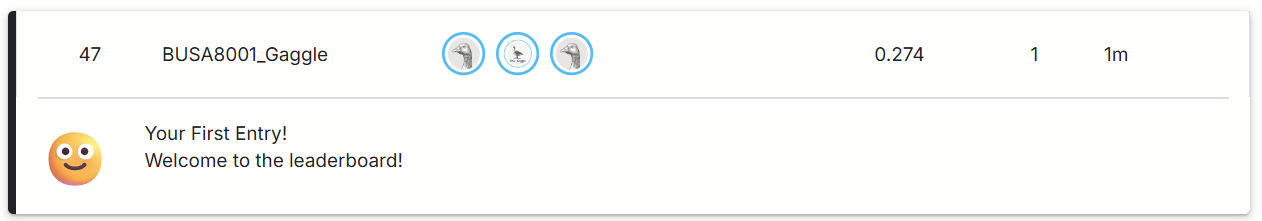

- Improved model Kaggle score, rank and screenshot are shown in Section 5.

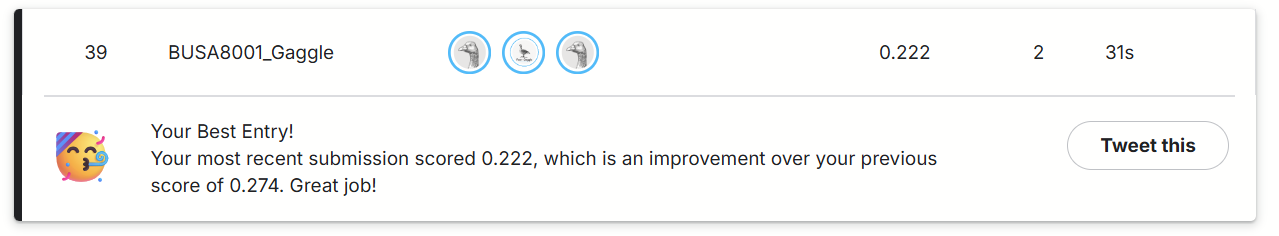

The main limitation is that the model only uses the cleaned and engineered features from Task 2. Other information, such as amenities, text descriptions, and more detailed date features, may improve prediction accuracy but would require extra feature engineering. A boosting ensemble such as `AdaBoostRegressor`, or a `StackingRegressor` combining the three models, would also be a natural next step beyond the Random Forest. We note that a much higher leaderboard rank was achievable by engineering `estimated_revenue_l365d / estimated_occupancy_l365d`, which reconstructs the nightly price almost exactly; however, as explained in Section 5 this is target leakage rather than a genuine forecasting signal, so it was deliberately excluded so that our reported performance reflects real predictive ability. Overall, the log-transformed Random Forest is our final model. Among the approaches we could genuinely justify, it gives the lowest real error (validation MAPE 22.77%, Kaggle 0.222), and because its leaderboard score closely matches its validation score, that performance is generalisable rather than overfit to one split. We chose it in preference to the higher-ranking revenue/occupancy approach because that alternative relies on target leakage. In short, it is the best model we can stand behind as a genuine forecast of Airbnb nightly price - not just the best leaderboard number.

---
